# Pandas 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('diabetes.csv')

### Chapter 1: Data Inspection and Selection

In [8]:
# to access the head elements of the dataset
df.head() # default is 5 but we can specify the number of rows we want to see
df.tail() # to access the last few rows of the dataset
df.sample(2) # to access random rows from the dataset

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefu,outcome
612,3,131,50,44,87,30.9,1.022,0
389,5,82,90,3,254,31.2,0.897,1


In [6]:
print("Shape", df.shape) # to check the number of rows and columns in the dataset
print("Columns", df.columns) # to check the column names in the dataset
print("Data Types", df.dtypes) # to check the data types of each column in the dataset

Shape (1000, 8)
Columns Index(['pregnancies', 'glucose', 'bloodpressure', 'skinthickness', 'insulin',
       'bmi', 'diabetespedigreefu', 'outcome'],
      dtype='str')
Data Types pregnancies             int64
glucose                 int64
bloodpressure           int64
skinthickness           int64
insulin                 int64
bmi                   float64
diabetespedigreefu    float64
outcome                 int64
dtype: object


In [7]:
glucose_col = df['glucose'] # to access a specific column in the dataset
glucose_col # to print the values of the glucose column

analysis_df = df[['glucose', 'insulin', 'bmi']] # to access multiple columns in the dataset
analysis_df.head(5)

,glucose,insulin,bmi
0,147,29,18.3
1,168,337,37.5
2,112,127,30.0
3,76,28,20.7
4,120,85,27.1


In [17]:
first_row = df.iloc[0:2, 2:5] # to access the first row of the dataset
first_row

subset = df.iloc[0:5, 0:3] # to access a subset of rows and columns from the dataset
subset

,pregnancies,glucose,bloodpressure
0,5,147,79
1,7,168,71
2,5,112,70
3,8,76,75
4,1,120,79


In [21]:
df['outcome'].value_counts() # to check the distribution of the target variable in the dataset
# df['bmi'].unique() # to check the unique values in the bmi column of the dataset

outcome
0    671
1    329
Name: count, dtype: int64

### Chapter 2: Filtering and Sorting

In [10]:
high_glucose = df[df['glucose'] > 120] # to filter the dataset based on a condition
high_glucose.sample(5)

no_diabetes = df[df['outcome'] == 0] # to filter the dataset based on a condition
no_diabetes.sample(5)

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefu,outcome
786,1,79,67,0,103,38.6,1.747,0
600,6,104,97,11,13,33.1,0.628,0
945,3,100,40,12,99,12.9,0.633,0
850,3,74,66,33,80,16.3,0.658,0
538,2,100,58,36,32,29.7,0.652,0


In [11]:
"""
It is required to wrap each condition in parentheses when using multiple conditions in pandas. This is because of the operator precedence in Python. The bitwise operators (& for AND, | for OR) have a higher precedence than the comparison operators (like >, ==). So, without parentheses, the expression would be evaluated in an unintended order, leading to incorrect results or errors.
"""
high_risk = df[(df['glucose'] > 120) & (df['bmi'] > 30)] # to filter the dataset based on multiple conditions using AND operator
high_risk.sample(5)

specific_cases = df[(df['pregnancies'] > 10) | (df['skinthickness'] > 40)] # to filter the dataset based on multiple conditions using OR operator
specific_cases.sample(5)

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefu,outcome
744,0,94,81,48,161,35.9,0.215,0
63,2,62,76,57,129,37.7,0.959,0
422,4,144,76,56,90,18.9,1.071,0
885,2,84,78,41,65,34.8,1.327,0
344,1,74,75,52,58,45.0,0.343,0


In [24]:
# filtering with .isin() method
"""
This method is more common for textual data but can also be used for numerical data. It allows us to filter the dataset based on multiple values in a column. For example, if we want to filter the dataset for mothers who have had 1, 2, or 3 pregnancies, we can use the .isin() method as follows:
"""
early_moms = df[df['glucose'].isin([100,125,110])] # to filter the dataset based on multiple values in a column using .isin() method
early_moms.sample(5)

df_sorted = df.sort_values(by='bmi', ascending=False) # to sort the dataset based on a specific column in descending order
df_sorted.head(5)

df_multiple_sorted = df.sort_values(by=['outcome', 'glucose'], ascending=[True, False]) # to sort the dataset based on multiple columns with different sorting orders
df_multiple_sorted.head(5)

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefu,outcome
448,1,199,60,26,72,29.0,0.605,0
802,2,198,74,19,65,28.5,0.300,0
362,2,192,66,30,20,29.0,0.463,0
849,2,187,76,23,104,42.4,0.800,0
954,5,187,72,26,30,34.7,0.556,0


In [33]:
# Selecting rows by logic

max_insulin_row = df[df['insulin'] == df['insulin'].max()] # to select the row with the maximum value in the insulin column
max_insulin_row


# find the average BMI of the people having diabetes
average_bmi_diabetes = df[df['outcome'] == 1]['bmi'].mean() # to calculate the average BMI of the people having diabetes
f"The average BMI of people having diabetes is: {average_bmi_diabetes:.2f}"

df[df['outcome'] == 1]['bmi'].mean()

np.float64(34.97537993920973)

### Chapter 3: Descriptive Statistics and Aggregation

In [14]:
# get overview of the stats of the dataset
df.describe()

avg_glucose = df['glucose'].mean() # to calculate the average glucose level in the dataset
f"The average glucose level in the dataset is: {avg_glucose:.2f}"

median_insulin = df['insulin'].median() # to calculate the median insulin level in the dataset
f"The median insulin level in the dataset is: {median_insulin:.2f}"

bmi_std = df['bmi'].std() # to calculate the standard deviation of the BMI in the dataset
f"The standard deviation of BMI in the dataset is: {bmi_std:.2f}"


'The standard deviation of BMI in the dataset is: 7.22'

In [15]:
# groupby  in pandas
grouped_by_outcome = df.groupby('outcome') # to group the dataset by the outcome column
grouped_by_outcome.mean()

df.groupby('outcome')[['insulin', 'glucose']].median() # to calculate the median insulin and glucose levels for each outcome group

,insulin,glucose
outcome,,
0,85.0,110.0
1,168.0,137.0


In [16]:
# multiple aggregation functions with groupby
df.groupby('outcome')['bmi'].agg(['mean', 'min', 'max']) # to calculate the mean, minimum, and maximum BMI for each outcome group using multiple aggregation functions with groupby


summary_stats = df.groupby('outcome').agg({
    'glucose': 'mean',
    'pregnancies': 'max',
    'bmi': 'std'
})
summary_stats

,glucose,pregnancies,bmi
outcome,,,
0,110.007452,8,6.893628
1,136.428571,11,6.550305


In [17]:
print(df['outcome'].value_counts()) # to check the distribution of the target variable in the dataset

print(df['outcome'].value_counts(normalize=True) * 100) # to check the distribution of the target variable in the dataset as proportions


outcome
0    671
1    329
Name: count, dtype: int64
outcome
0    67.1
1    32.9
Name: proportion, dtype: float64


In [18]:
# correlation matrix
correlation_matrix = df.corr() # to calculate the correlation matrix of the dataset
correlation_matrix

# focus on how outcome correlates with other features in the dataset
"""
This tells which features are the best predictors for the target variable (outcome) in the dataset. A higher positive correlation indicates a stronger positive relationship between the feature and the outcome, while a higher negative correlation indicates a stronger negative relationship. By sorting the correlation values in descending order, we can identify which features are most strongly correlated with the outcome, which can be useful for feature selection and understanding the underlying relationships in the data.
"""
print(correlation_matrix['outcome'].sort_values(ascending=False))

outcome               1.000000
pregnancies           0.462515
insulin               0.414966
glucose               0.390533
bmi                   0.342955
bloodpressure         0.178645
skinthickness         0.103352
diabetespedigreefu    0.036681
Name: outcome, dtype: float64


## Chapter 4: Data Cleaning (Handling Zeros and Nulls)

In [19]:
# find the columns with zeros
cols_to_fix = ['glucose', 'bloodpressure', 'skinthickness', 'insulin', 'bmi'] # to identify the columns that contain zeros which are likely to be invalid entries in the dataset
(df[cols_to_fix] == 0).sum() # to count the number of zeros in each of the specified columns


# now convert the zeros to NaN values

df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan) # to replace the zeros in the specified columns with NaN values
(df[cols_to_fix] == 0).sum() # Now it contains no zeros in any columns

glucose          0
bloodpressure    0
skinthickness    0
insulin          0
bmi              0
dtype: int64

In [20]:
# fill the NAN values with the median of the columns
for col in cols_to_fix:
    median_value = df[col].median() # to calculate the median value of the column
    df[col].fillna(median_value) # to fill the NaN values in the column with the median value

# we can also include the groupby clause to fill the NaN values with the median of the columns for each outcome group separately
df['skinthickness'] = df.groupby('outcome')['skinthickness'].transform(lambda x: x.fillna(x.median())) # to fill the NaN values in the skinthickness column with the median value for each outcome group separately

In [21]:
# we can drop the rows with NaN values instead of filling them
df_cleaned = df.dropna() # to drop the rows with NaN values from the dataset

# we can also drop a entirely column if it contains too many NaN values
df_reduced = df.drop(columns=['skinthickness']) # to drop the skinthickness column from the dataset if it contains too many NaN values
df_reduced

,pregnancies,glucose,bloodpressure,insulin,bmi,diabetespedigreefu,outcome
0,5,147,79,29,18.3,0.550,0
1,7,168,71,337,37.5,0.698,1
2,5,112,70,127,30.0,0.644,1
3,8,76,75,28,20.7,0.952,0
4,1,120,79,85,27.1,0.685,0
...,...,...,...,...,...,...,...
995,3,50,85,27,28.4,0.766,0
996,5,122,78,164,39.3,0.910,1
997,3,74,65,30,29.9,0.541,0
998,6,141,59,221,33.6,1.183,1


In [22]:
# count the duplicate rows in the dataset
duplicate_count = df.duplicated().sum() # to count the number of duplicate rows in the dataset
f"The number of duplicate rows in the dataset is: {duplicate_count}"

df = df.drop_duplicates() # to drop the duplicate rows from the dataset

df

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefu,outcome
0,5,147,79,39.0,29,18.3,0.550,0
1,7,168,71,27.0,337,37.5,0.698,1
2,5,112,70,16.0,127,30.0,0.644,1
3,8,76,75,27.0,28,20.7,0.952,0
4,1,120,79,7.0,85,27.1,0.685,0
...,...,...,...,...,...,...,...,...
995,3,50,85,6.0,27,28.4,0.766,0
996,5,122,78,24.0,164,39.3,0.910,1
997,3,74,65,16.0,30,29.9,0.541,0
998,6,141,59,18.0,221,33.6,1.183,1


## Chapter 5: Feature Engineering and Pre-Visualisation

In [23]:
"""
Sometimes it is good to engineer or make new columns that helps to visualise the data better using seaborn or matplotlib. Such as bmi can be made categorical by defining ranges for underweight, normal weight, overweight, and obese. This can help in visualizing the distribution of BMI categories among diabetic and non-diabetic patients, making it easier to identify patterns and insights in the data.
"""

# create a new column for BMI categories
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal weight'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'
    

df['bmi_category'] = df['bmi'].apply(bmi_category) # to create a new column for BMI categories by applying the bmi_category function to the bmi column
df[['bmi', 'bmi_category']].head() # to check the new column for BMI categories along with the original BMI values

,bmi,bmi_category
0,18.3,Underweight
1,37.5,Obese
2,30.0,Obese
3,20.7,Normal weight
4,27.1,Overweight


In [24]:
# creating high flags for high glucose patients

df['glucose_high_flag'] = df['glucose'] > 120 # to create a new column that flags high glucose levels by checking if the glucose value is greater than 120
df[['glucose', 'glucose_high_flag']].head() # to check the new column for high glucose flags along with the original glucose values

,glucose,glucose_high_flag
0,147,True
1,168,True
2,112,False
3,76,False
4,120,False


In [25]:
df.rename(columns={'bloodpressure': 'bp', 'diabetespedigreefunction': 'dpf'}, inplace=True) # to rename the columns in the dataset for better readability and convenience
df.head() # to check the renamed columns in the dataset

,pregnancies,glucose,bp,skinthickness,insulin,bmi,diabetespedigreefu,outcome,bmi_category,glucose_high_flag
0,5,147,79,39.0,29,18.3,0.550,0,Underweight,True
1,7,168,71,27.0,337,37.5,0.698,1,Obese,True
2,5,112,70,16.0,127,30.0,0.644,1,Obese,False
3,8,76,75,27.0,28,20.7,0.952,0,Normal weight,False
4,1,120,79,7.0,85,27.1,0.685,0,Overweight,False


## Chapter 6: Visualising Distribution and Relationships

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style="whitegrid")

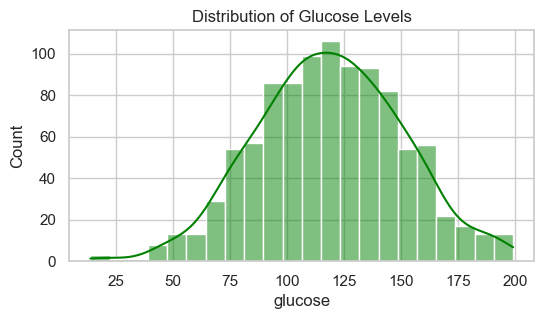

In [31]:
plt.figure(figsize=(6, 3))
sns.histplot(data=df, x='glucose', kde=True, color='green')
plt.title('Distribution of Glucose Levels') # to set the title of the plot
plt.show() # to display the plot

C:\Users\Arpan\AppData\Local\Temp\ipykernel_23388\1160547436.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='outcome', y='bmi', palette='Set2')


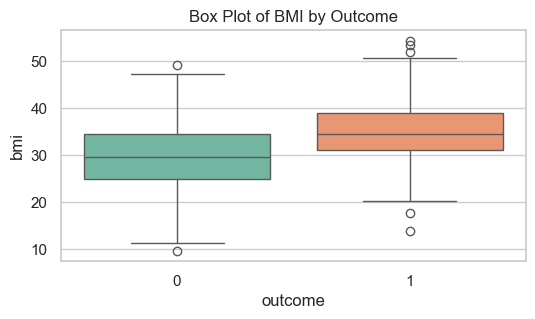

In [33]:
plt.figure(figsize=(6, 3))
sns.boxplot(data=df, x='outcome', y='bmi', palette='Set2')
plt.title('Box Plot of BMI by Outcome')
plt.show()

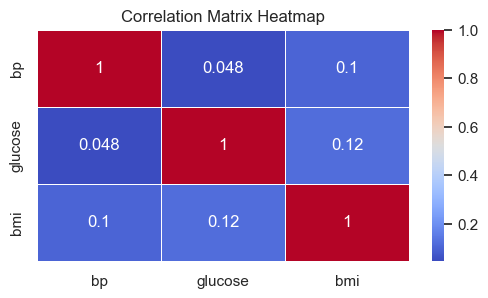

In [38]:
plt.figure(figsize=(6, 3))
correlation_matrix = df[['bp', 'glucose', 'bmi']].corr(numeric_only=True) # to calculate the correlation matrix of the dataset
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5) # to create a heatmap of the correlation matrix with annotations and a specific color map
plt.title('Correlation Matrix Heatmap') # to set the title of the heatmap
plt.show() # to display the heatmap

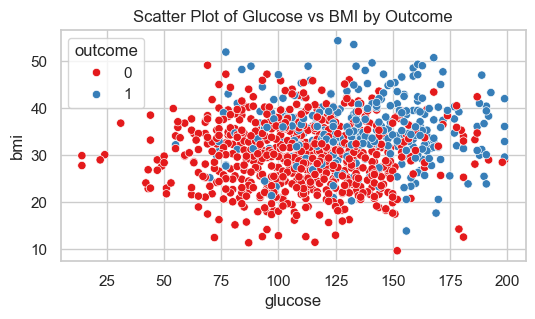

In [40]:
plt.figure(figsize=(6, 3))
sns.scatterplot(data=df, x='glucose', y='bmi', hue='outcome', palette='Set1')
plt.title('Scatter Plot of Glucose vs BMI by Outcome')  
plt.show()

C:\Users\Arpan\AppData\Local\Temp\ipykernel_23388\3845189173.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='outcome', y='insulin', palette='Set3')


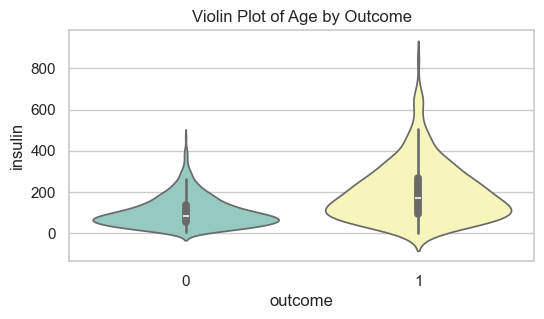

In [42]:
plt.figure(figsize=(6, 3))
sns.violinplot(data=df, x='outcome', y='insulin', palette='Set3')
plt.title('Violin Plot of Age by Outcome') 
plt.show()

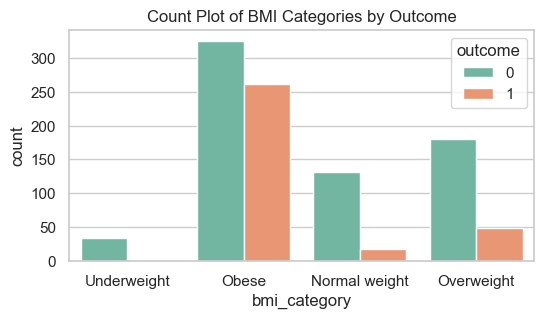

In [43]:
plt.figure(figsize=(6, 3))
sns.countplot(data=df, x='bmi_category', hue='outcome', palette='Set2')
plt.title('Count Plot of BMI Categories by Outcome')    
plt.show()

<Figure size 600x300 with 0 Axes>

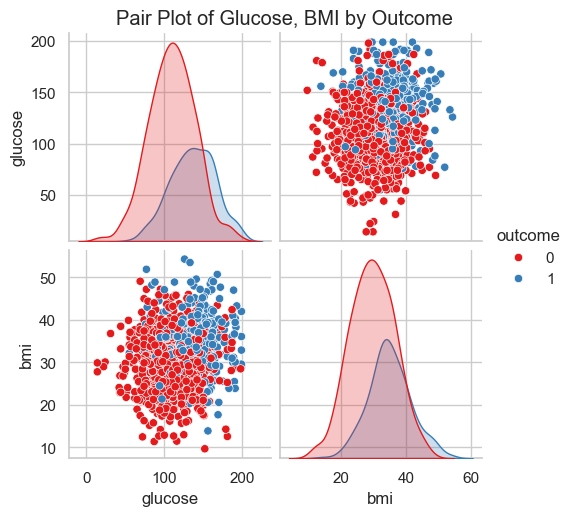

In [46]:
plt.figure(figsize=(6, 3))
sns.pairplot(data=df, vars=['glucose', 'bmi'], hue='outcome', palette='Set1')
plt.suptitle('Pair Plot of Glucose, BMI by Outcome', y = 1.02) # to set the title of the pair plot with a specific position
plt.show()